# Transfer learning en CIFAR-10: CNN desde cero vs. VGG-16 (feature extractor y fine-tuning)


In [1]:
!pip -q install torchinfo fvcore

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 4.2 MB/s eta 0:00:00


In [2]:
import os, gc, json, time, copy, random, math
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.nn.functional as F
from torchvision import datasets, transforms
from torchvision.models import vgg16, VGG16_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report)
from torchinfo import summary
from fvcore.nn import FlopCountAnalysis

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
assert device.type == 'cuda', 'Activa la GPU en Colab'
torch.backends.cudnn.benchmark = True

VGG_IMG = 128      # misma resolución para ambos modelos VGG (224 si hay cómputo de sobra)
BATCH = 128
USE_DRIVE = False  # True para persistir resultados/pesos en Drive
RESULTS_DIR = '/content/drive/MyDrive/lab_cifar_tl' if USE_DRIVE else '/content/results'
if USE_DRIVE:
    from google.colab import drive; drive.mount('/content/drive')
os.makedirs(RESULTS_DIR, exist_ok=True)

In [3]:
# Hardware utilizado (para el reporte)
print('GPU :', torch.cuda.get_device_name(0))
print('VRAM: %.1f GB' % (torch.cuda.get_device_properties(0).total_memory / 1e9))
print('torch', torch.__version__)
!lscpu | grep -E "Model name|^CPU\(s\)"

GPU : Tesla T4
VRAM: 15.6 GB
torch 2.11.0+cu128
CPU(s):                                  2
Model name:                              Intel(R) Xeon(R) CPU @ 2.00GHz


## 1–2. Dataset, exploración y preparación

In [4]:
train_ds = datasets.CIFAR10(root='data', train=True, download=True)
test_ds  = datasets.CIFAR10(root='data', train=False, download=True)
CLASSES = train_ds.classes
Xtr_np, ytr_np = train_ds.data, np.array(train_ds.targets)   # (50000, 32, 32, 3) uint8
Xte_np, yte_np = test_ds.data,  np.array(test_ds.targets)

print(f'Observaciones: train={len(ytr_np)}, test={len(yte_np)}, total={len(ytr_np)+len(yte_np)}')
print(f'Clases ({len(CLASSES)}):', CLASSES)
print('Forma de una imagen (H, W, C):', Xtr_np.shape[1:])
display(pd.DataFrame({'train': np.bincount(ytr_np), 'test': np.bincount(yte_np)}, index=CLASSES).T)

100%|██████████| 170M/170M [25:45<00:00, 110kB/s]


Observaciones: train=50000, test=10000, total=60000
Clases (10): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Forma de una imagen (H, W, C): (32, 32, 3)


,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck
train,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000
test,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000


In [5]:
# Split estratificado 45k/5k + subconjunto estratificado del 10% para la sección 4.1
all_idx = np.arange(len(ytr_np))
tr_idx, va_idx = train_test_split(all_idx, test_size=5000, stratify=ytr_np, random_state=SEED)
tr10_idx, _ = train_test_split(tr_idx, train_size=0.10, stratify=ytr_np[tr_idx], random_state=SEED)
print('train:', len(tr_idx), '| val:', len(va_idx), '| train 10%:', len(tr10_idx))
print('por clase val   :', np.bincount(ytr_np[va_idx]))
print('por clase 10%   :', np.bincount(ytr_np[tr10_idx]))

train: 45000 | val: 5000 | train 10%: 4500
por clase val   : [500 500 500 500 500 500 500 500 500 500]
por clase 10%   : [450 450 450 450 450 450 450 450 450 450]


In [6]:
# Media y std por canal sobre el split de entrenamiento vs. ImageNet
x = Xtr_np[tr_idx].astype(np.float32) / 255.
CIFAR_MEAN, CIFAR_STD = x.mean(axis=(0, 1, 2)), x.std(axis=(0, 1, 2))
IMNET_MEAN, IMNET_STD = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
del x
display(pd.DataFrame({'CIFAR mean': CIFAR_MEAN, 'ImageNet mean': IMNET_MEAN,
                      'CIFAR std': CIFAR_STD, 'ImageNet std': IMNET_STD}, index=['R', 'G', 'B']).round(4))

,CIFAR mean,ImageNet mean,CIFAR std,ImageNet std
R,0.4911,0.485,0.2469,0.229
G,0.4821,0.456,0.2434,0.224
B,0.4464,0.406,0.2616,0.225


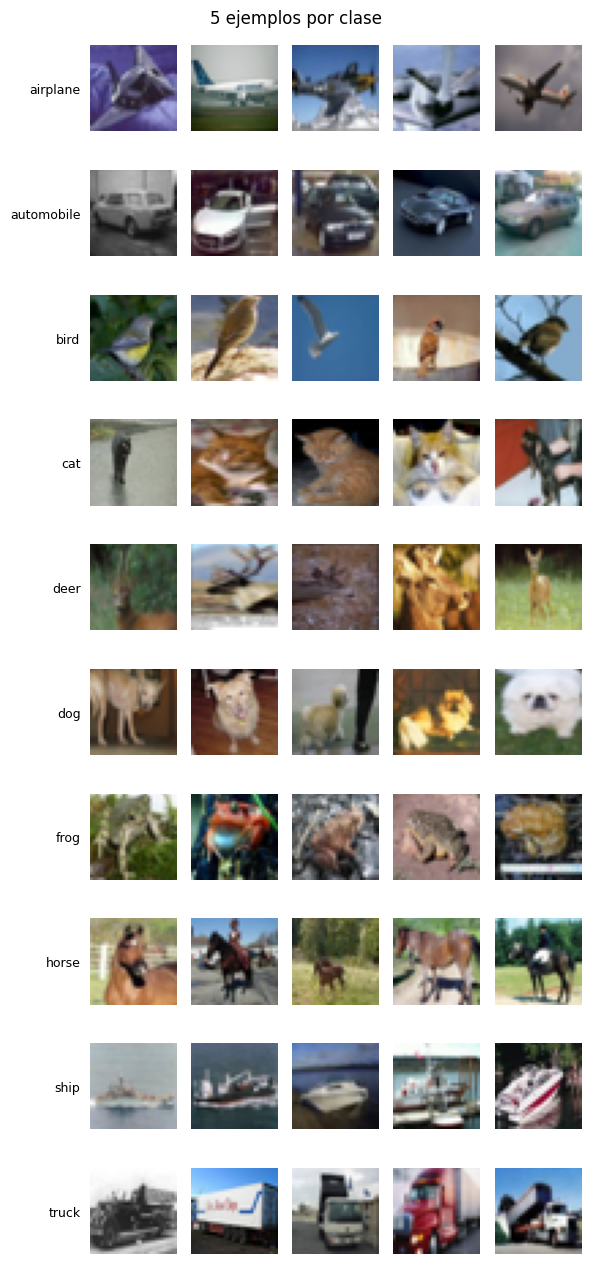

In [7]:
fig, axes = plt.subplots(10, 5, figsize=(6, 13))
rng = np.random.default_rng(SEED)
for c in range(10):
    for j, i in enumerate(rng.choice(np.where(ytr_np == c)[0], 5, replace=False)):
        axes[c, j].imshow(Xtr_np[i]); axes[c, j].axis('off')
    axes[c, 0].text(-4, 16, CLASSES[c], ha='right', va='center', fontsize=9)
plt.suptitle('5 ejemplos por clase'); plt.tight_layout(); plt.show()

In [8]:
for s in [32, 112, 128, 224]:
    print(f'{s:>3}x{s:<3}: {s*s:>6} px/canal ({3*s*s:>6} valores) -> x{s*s/1024:5.1f} píxeles y ~cómputo conv vs 32x32')

 32x32 :   1024 px/canal (  3072 valores) -> x  1.0 píxeles y ~cómputo conv vs 32x32
112x112:  12544 px/canal ( 37632 valores) -> x 12.2 píxeles y ~cómputo conv vs 32x32
128x128:  16384 px/canal ( 49152 valores) -> x 16.0 píxeles y ~cómputo conv vs 32x32
224x224:  50176 px/canal (150528 valores) -> x 49.0 píxeles y ~cómputo conv vs 32x32


In [9]:
# Pipelines de referencia (equivalentes a lo que hace GPULoader)
cnn_train_tf = transforms.Compose([transforms.RandomCrop(32, padding=4), transforms.RandomHorizontalFlip(),
                                   transforms.ToTensor(), transforms.Normalize(CIFAR_MEAN, CIFAR_STD)])
cnn_eval_tf  = transforms.Compose([transforms.ToTensor(), transforms.Normalize(CIFAR_MEAN, CIFAR_STD)])
vgg_train_tf = transforms.Compose([transforms.RandomCrop(32, padding=4), transforms.RandomHorizontalFlip(),
                                   transforms.Resize(VGG_IMG), transforms.ToTensor(),
                                   transforms.Normalize(IMNET_MEAN, IMNET_STD)])
vgg_eval_tf  = transforms.Compose([transforms.Resize(VGG_IMG), transforms.ToTensor(),
                                   transforms.Normalize(IMNET_MEAN, IMNET_STD)])
print('Preset oficial VGG16:', VGG16_Weights.IMAGENET1K_V1.transforms())

Preset oficial VGG16: ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [10]:
PREP = {'cnn': dict(size=32, mean=CIFAR_MEAN, std=CIFAR_STD),
        'vgg': dict(size=VGG_IMG, mean=IMNET_MEAN, std=IMNET_STD)}
KIND = {'cnn': 'cnn', 'fe': 'vgg', 'ft': 'vgg'}

to_gpu = lambda X: torch.from_numpy(X).permute(0, 3, 1, 2).contiguous().to(device)  # uint8 NCHW
Xtr_gpu, ytr_gpu = to_gpu(Xtr_np), torch.from_numpy(ytr_np).to(device)
Xte_gpu, yte_gpu = to_gpu(Xte_np), torch.from_numpy(yte_np).to(device)

def gpu_augment(x, pad=4):
    # RandomCrop(32, padding=4) + RandomHorizontalFlip por muestra
    B, C, H, W = x.shape
    xp = F.pad(x, (pad,) * 4)
    i = torch.randint(0, 2 * pad + 1, (B, 1), device=x.device)
    j = torch.randint(0, 2 * pad + 1, (B, 1), device=x.device)
    rows = (i + torch.arange(H, device=x.device))[:, None, :, None]
    cols = (j + torch.arange(W, device=x.device))[:, None, None, :]
    b = torch.arange(B, device=x.device)[:, None, None, None]
    c = torch.arange(C, device=x.device)[None, :, None, None]
    out = xp[b, c, rows, cols]
    flip = torch.rand(B, device=x.device) < 0.5
    return torch.where(flip[:, None, None, None], out.flip(3), out)

class GPULoader:
    def __init__(self, X, y, idx, kind, shuffle, aug, bs=BATCH):
        idx = torch.as_tensor(np.asarray(idx), device=X.device)
        self.X, self.y, self.shuffle, self.aug, self.bs = X[idx], y[idx], shuffle, aug, bs
        p = PREP[kind]; self.size = p['size']
        self.mean = torch.tensor(p['mean'], dtype=torch.float32, device=X.device).view(1, 3, 1, 1)
        self.std  = torch.tensor(p['std'],  dtype=torch.float32, device=X.device).view(1, 3, 1, 1)
    def __len__(self): return math.ceil(len(self.y) / self.bs)
    def __iter__(self):
        n = len(self.y)
        order = torch.randperm(n, device=self.y.device) if self.shuffle else torch.arange(n, device=self.y.device)
        for k in range(0, n, self.bs):
            b = order[k:k + self.bs]
            x = self.X[b].float().div_(255)
            if self.aug: x = gpu_augment(x)
            if self.size != 32:
                x = F.interpolate(x, size=(self.size, self.size), mode='bilinear', align_corners=False)
            yield (x - self.mean) / self.std, self.y[b]

def make_loaders(kind, aug=True, train_idx=None):
    train_idx = tr_idx if train_idx is None else train_idx
    return (GPULoader(Xtr_gpu, ytr_gpu, train_idx, kind, shuffle=True, aug=aug),
            GPULoader(Xtr_gpu, ytr_gpu, va_idx, kind, shuffle=False, aug=False))

test_loader = {k: GPULoader(Xte_gpu, yte_gpu, np.arange(len(yte_np)), k, False, False) for k in PREP}

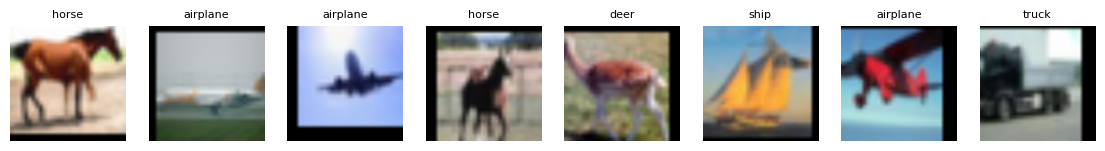

In [11]:
# Verificación visual de la augmentation (pipeline VGG)
dl, _ = make_loaders('vgg', aug=True)
x, y = next(iter(dl))
m, s = dl.mean, dl.std
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for a, img, t in zip(axes, (x[:8] * s + m).clamp(0, 1).permute(0, 2, 3, 1).cpu(), y[:8].cpu()):
    a.imshow(img); a.set_title(CLASSES[t], fontsize=8); a.axis('off')
plt.show(); del dl, x, y

In [12]:
# Demostración rápida de lo investigado
w = VGG16_Weights.IMAGENET1K_V1
demo = vgg16(weights=w)
print(demo.avgpool); print(demo.classifier)
print('Bloques de features:', [demo.features[s:e] for s, e in [(24, 31)]])
for p in demo.features.parameters(): p.requires_grad = False
demo.classifier[6] = nn.Linear(4096, 10)
tot = sum(p.numel() for p in demo.parameters()); tr = sum(p.numel() for p in demo.parameters() if p.requires_grad)
print(f'Totales: {tot/1e6:.2f} M | entrenables (solo classifier): {tr/1e6:.2f} M')
summary(demo, input_size=(1, 3, VGG_IMG, VGG_IMG), col_names=('output_size', 'num_params', 'trainable', 'mult_adds'), depth=2)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 138MB/s]


AdaptiveAvgPool2d(output_size=(7, 7))
Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)
Bloques de features: [Sequential(
  (24): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (25): ReLU(inplace=True)
  (26): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (27): ReLU(inplace=True)
  (28): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (29): ReLU(inplace=True)
  (30): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)]
Totales: 134.30 M | entrenables (solo classifier): 119.59 M


Layer (type:depth-idx)                   Output Shape              Param #                   Trainable                 Mult-Adds
VGG                                      [1, 10]                   --                        Partial                   --
├─Sequential: 1-1                        [1, 512, 4, 4]            --                        False                     --
│    └─Conv2d: 2-1                       [1, 64, 128, 128]         (1,792)                   False                     29,360,128
│    └─ReLU: 2-2                         [1, 64, 128, 128]         --                        --                        --
│    └─Conv2d: 2-3                       [1, 64, 128, 128]         (36,928)                  False                     605,028,352
│    └─ReLU: 2-4                         [1, 64, 128, 128]         --                        --                        --
│    └─MaxPool2d: 2-5                    [1, 64, 64, 64]           --                        --                        --


In [13]:
del demo; gc.collect(); torch.cuda.empty_cache()

## 4. Modelos y entrenamiento

In [14]:
class ConvBlock(nn.Sequential):
    def __init__(self, cin, cout, p):
        super().__init__(
            nn.Conv2d(cin, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
            nn.Conv2d(cout, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout(p))

class SimpleCNN(nn.Module):
    def __init__(self, widths=(64, 128, 256), drop=0.25, fc_drop=0.5, n_classes=10):
        super().__init__()
        blocks, cin = [], 3
        for w in widths:
            blocks.append(ConvBlock(cin, w, drop)); cin = w
        self.features = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(fc_drop), nn.Linear(cin, n_classes))
    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))

VGG_BLOCKS = [(0, 5), (5, 10), (10, 17), (17, 24), (24, 31)]

def build_vgg(n_unfrozen=0, head_drop=0.5):
    m = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
    m.features.requires_grad_(False)
    for b in range(5 - n_unfrozen, 5):          # descongela los n bloques superiores
        s, e = VGG_BLOCKS[b]; m.features[s:e].requires_grad_(True)
    m.classifier[2].p = m.classifier[5].p = head_drop
    m.classifier[6] = nn.Linear(4096, 10)
    return m

def build_model(cfg):
    if cfg['family'] == 'cnn':
        return SimpleCNN(cfg['widths'], cfg['drop'], cfg['fc_drop'])
    return build_vgg(cfg.get('n_unfrozen', 0), cfg.get('head_drop', 0.5))

def count_params(m):
    return sum(p.numel() for p in m.parameters()), sum(p.numel() for p in m.parameters() if p.requires_grad)

def frozen_desc(c):
    if c['family'] == 'cnn': return 'ninguna'
    k = c.get('n_unfrozen', 0)
    return f'features bloques 1-{5-k}' + ('' if k else ' (todo el backbone)')

def build_optimizer(model, cfg):
    if cfg['family'] == 'ft':
        groups = [{'params': [p for p in model.features.parameters() if p.requires_grad], 'lr': cfg['lr_bb']},
                  {'params': model.classifier.parameters(), 'lr': cfg['lr']}]
    else:
        groups = [{'params': [p for p in model.parameters() if p.requires_grad], 'lr': cfg['lr']}]
    if cfg.get('opt', 'adamw') == 'sgd':
        return torch.optim.SGD(groups, lr=cfg['lr'], momentum=0.9, nesterov=True, weight_decay=cfg.get('wd', 5e-4))
    return torch.optim.AdamW(groups, lr=cfg['lr'], weight_decay=cfg.get('wd', 1e-4))

In [15]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    loss_sum, preds, ys = torch.zeros((), device=device), [], []
    for x, y in loader:
        with torch.autocast('cuda', dtype=torch.float16):
            out = model(x)
        loss_sum += F.cross_entropy(out.float(), y, reduction='sum')
        preds.append(out.argmax(1)); ys.append(y)
    p, t = torch.cat(preds).cpu().numpy(), torch.cat(ys).cpu().numpy()
    pr, rc, f1, _ = precision_recall_fscore_support(t, p, average='macro', zero_division=0)
    return dict(loss=loss_sum.item() / len(t), acc=accuracy_score(t, p), precision=pr, recall=rc, f1=f1), t, p

def train_model(cfg, train_idx=None):
    set_seed(cfg.get('seed', SEED))
    train_idx = tr_idx if train_idx is None else train_idx
    train_loader, val_loader = make_loaders(KIND[cfg['family']], cfg.get('aug', True), train_idx)
    gc.collect(); torch.cuda.empty_cache()
    base_mem = torch.cuda.memory_allocated()
    torch.cuda.reset_peak_memory_stats()
    model = build_model(cfg).to(device)
    opt = build_optimizer(model, cfg)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg['epochs'])
    scaler = torch.amp.GradScaler('cuda')
    crit = nn.CrossEntropyLoss()
    total, trainable = count_params(model)
    keys = ['train_loss', 'val_loss', 'val_acc', 'val_precision', 'val_recall', 'val_f1', 'epoch_time']
    hist = {k: [] for k in keys}
    best_f1, best_ep, best_state, wait = -1, 0, None, 0

    for ep in range(1, cfg['epochs'] + 1):
        model.train()
        run_loss, n = torch.zeros((), device=device), 0
        torch.cuda.synchronize(); t0 = time.perf_counter()
        for x, y in train_loader:
            with torch.autocast('cuda', dtype=torch.float16):
                loss = crit(model(x), y)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            run_loss += loss.detach() * len(y); n += len(y)
        torch.cuda.synchronize(); ep_time = time.perf_counter() - t0
        sched.step()

        m, _, _ = evaluate(model, val_loader)
        for k, v in zip(keys, [run_loss.item() / n, m['loss'], m['acc'], m['precision'], m['recall'], m['f1'], ep_time]):
            hist[k].append(float(v))
        print(f"ep {ep:02d} | train {hist['train_loss'][-1]:.4f} | val {m['loss']:.4f} | "
              f"acc {m['acc']:.4f} | f1 {m['f1']:.4f} | {ep_time:.1f}s")
        if m['f1'] > best_f1:
            best_f1, best_ep, wait = m['f1'], ep, 0
            best_state = {k: v.detach().to('cpu', copy=True) for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= cfg.get('patience', 999):
                print('early stopping'); break

    peak = (torch.cuda.max_memory_allocated() - base_mem) / 1e9
    model.load_state_dict(best_state)
    b = best_ep - 1
    res = dict(name=cfg['name'], family=cfg['family'], cfg=cfg, hist=hist,
               frac=round(len(train_idx) / len(tr_idx), 3), train_size=len(train_idx),
               total_params=total, trainable_params=trainable, frozen=frozen_desc(cfg),
               best_epoch=best_ep, epochs_run=len(hist['train_loss']),
               best_val={k: hist['val_' + k][b] for k in ['loss', 'acc', 'precision', 'recall', 'f1']},
               time_per_epoch=float(np.mean(hist['epoch_time'])), time_total=float(np.sum(hist['epoch_time'])),
               time_to_best=float(np.sum(hist['epoch_time'][:best_ep])), peak_mem_gb=peak)
    return res, model

In [16]:
RES_PATH = f'{RESULTS_DIR}/results.json'
ALL_RESULTS = json.load(open(RES_PATH)) if os.path.exists(RES_PATH) else {}

def save_results():
    with open(RES_PATH, 'w') as f:
        json.dump(ALL_RESULTS, f, default=lambda o: o.item() if hasattr(o, 'item') else list(o) if isinstance(o, tuple) else str(o))

def run_iterations(cfgs):
    for cfg in cfgs:
        if cfg['name'] in ALL_RESULTS:
            print(f"{cfg['name']} ya existe, se omite"); continue
        print(f"\n===== {cfg['name']} =====")
        res, model = train_model(cfg)
        fam = cfg['family']
        prev = [r['best_val']['f1'] for r in ALL_RESULTS.values() if r['family'] == fam and r['frac'] == 1.0]
        if not prev or res['best_val']['f1'] > max(prev):
            torch.save(model.state_dict(), f'{RESULTS_DIR}/best_{fam}.pt'); print(f'-> nuevo mejor modelo {fam}')
        ALL_RESULTS[cfg['name']] = res; save_results()
        del model; gc.collect(); torch.cuda.empty_cache()

def iter_table(fam=None, frac=1.0):
    rows = []
    for r in ALL_RESULTS.values():
        if (fam and r['family'] != fam) or r['frac'] != frac: continue
        c, bv = r['cfg'], r['best_val']
        rows.append({'iter': r['name'],
                     'config': ', '.join(f'{k}={v}' for k, v in c.items() if k not in ('name', 'family')),
                     'congeladas': r['frozen'], 'params tot (M)': r['total_params'] / 1e6,
                     'params entr (M)': r['trainable_params'] / 1e6, 'best ep': r['best_epoch'],
                     'epochs': r['epochs_run'], 'val acc': bv['acc'], 'val prec': bv['precision'],
                     'val rec': bv['recall'], 'val F1': bv['f1'], 's/epoch': r['time_per_epoch'],
                     'total (min)': r['time_total'] / 60, 'GPU pico (GB)': r['peak_mem_gb']})
    return pd.DataFrame(rows).round(4)

def plot_losses(fam):
    runs = [r for r in ALL_RESULTS.values() if r['family'] == fam and r['frac'] == 1.0]
    fig, axes = plt.subplots(1, len(runs), figsize=(4.8 * len(runs), 3.4), squeeze=False)
    for ax, r in zip(axes[0], runs):
        e = range(1, r['epochs_run'] + 1)
        ax.plot(e, r['hist']['train_loss'], label='train'); ax.plot(e, r['hist']['val_loss'], label='val')
        ax.axvline(r['best_epoch'], ls='--', c='gray', lw=1)
        ax.set_title(f"{r['name']} (val F1={r['best_val']['f1']:.3f})", fontsize=10); ax.set_xlabel('epoch'); ax.legend()
    axes[0][0].set_ylabel('cross-entropy'); plt.tight_layout(); plt.show()

def epoch_table(name):
    h = ALL_RESULTS[name]['hist']
    return pd.DataFrame(h, index=pd.RangeIndex(1, len(h['train_loss']) + 1, name='epoch')).round(4)

### 4.a CNN desde cero (32×32)


In [17]:
CNN_CFGS = [
    dict(name='cnn_it1', family='cnn', widths=(32, 64, 128), drop=0.0, fc_drop=0.0, aug=False,
         opt='adamw', lr=1e-3, wd=5e-4, epochs=30, patience=8),
    dict(name='cnn_it2', family='cnn', widths=(64, 128, 256), drop=0.25, fc_drop=0.5, aug=True,
         opt='adamw', lr=1e-3, wd=5e-4, epochs=30, patience=8),
    dict(name='cnn_it3', family='cnn', widths=(64, 128, 256, 512), drop=0.25, fc_drop=0.5, aug=True,
         opt='sgd', lr=0.05, wd=5e-4, epochs=40, patience=10),
]
run_iterations(CNN_CFGS)


===== cnn_it1 =====
ep 01 | train 1.2467 | val 1.3525 | acc 0.5338 | f1 0.5335 | 24.6s
ep 02 | train 0.8216 | val 0.9321 | acc 0.6832 | f1 0.6896 | 2.6s
ep 03 | train 0.6611 | val 0.9498 | acc 0.6790 | f1 0.6924 | 2.6s
ep 04 | train 0.5559 | val 0.7286 | acc 0.7536 | f1 0.7553 | 2.7s
ep 05 | train 0.4812 | val 0.8946 | acc 0.7126 | f1 0.7183 | 2.7s
ep 06 | train 0.4192 | val 0.5518 | acc 0.8174 | f1 0.8162 | 2.5s
ep 07 | train 0.3606 | val 0.6007 | acc 0.8042 | f1 0.8027 | 2.6s
ep 08 | train 0.3086 | val 0.6731 | acc 0.7882 | f1 0.7856 | 2.5s
ep 09 | train 0.2657 | val 0.7107 | acc 0.7848 | f1 0.7828 | 2.9s
ep 10 | train 0.2175 | val 0.6210 | acc 0.8100 | f1 0.8100 | 2.6s
ep 11 | train 0.1789 | val 0.5319 | acc 0.8380 | f1 0.8380 | 2.5s
ep 12 | train 0.1420 | val 0.6425 | acc 0.8180 | f1 0.8167 | 2.5s
ep 13 | train 0.1096 | val 0.5974 | acc 0.8238 | f1 0.8237 | 2.6s
ep 14 | train 0.0797 | val 0.6816 | acc 0.8142 | f1 0.8127 | 2.9s
ep 15 | train 0.0653 | val 0.8421 | acc 0.7878 | f1 0.

,iter,config,congeladas,params tot (M),params entr (M),best ep,epochs,val acc,val prec,val rec,val F1,s/epoch,total (min),GPU pico (GB)
0,cnn_it1,"widths=(32, 64, 128), drop=0.0, fc_drop=0.0, a...",ninguna,0.2887,0.2887,23,30,0.8566,0.8566,0.8566,0.8564,3.4251,1.7126,0.3423
1,cnn_it2,"widths=(64, 128, 256), drop=0.25, fc_drop=0.5,...",ninguna,1.1489,1.1489,29,30,0.9024,0.9021,0.9024,0.9020,6.2871,3.1436,0.6685
2,cnn_it3,"widths=(64, 128, 256, 512), drop=0.25, fc_drop...",ninguna,4.6924,4.6924,39,40,0.9278,0.9281,0.9278,0.9276,6.8565,4.5710,0.8138


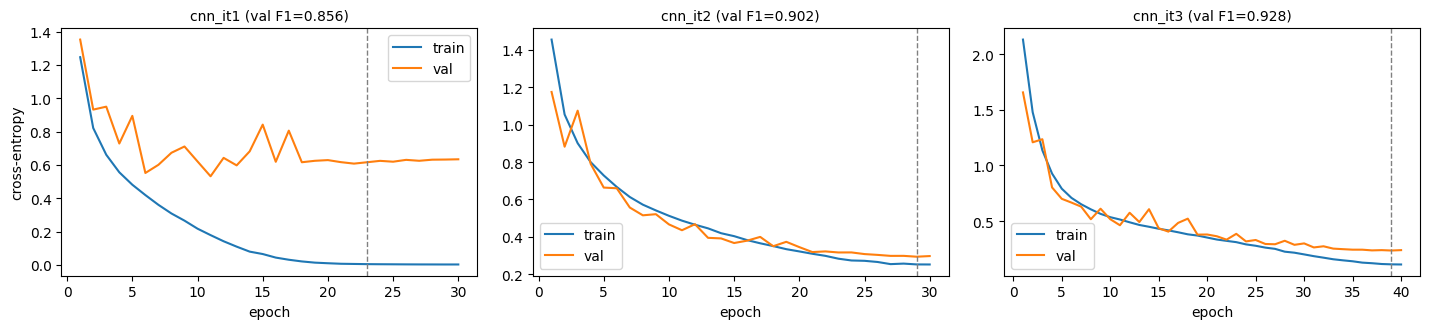

In [18]:
display(iter_table('cnn')); plot_losses('cnn')

### 4.b VGG-16 como feature extractor


In [19]:
FE_CFGS = [
    dict(name='fe_it1', family='fe', aug=False, head_drop=0.5, opt='adamw', lr=1e-4, wd=1e-4, epochs=8, patience=3),
    dict(name='fe_it2', family='fe', aug=True,  head_drop=0.5, opt='adamw', lr=1e-4, wd=1e-4, epochs=8, patience=3),
    dict(name='fe_it3', family='fe', aug=True,  head_drop=0.5, opt='sgd',   lr=1e-3, wd=5e-4, epochs=8, patience=3),
]
run_iterations(FE_CFGS)


===== fe_it1 =====
ep 01 | train 0.5198 | val 0.3703 | acc 0.8686 | f1 0.8678 | 55.5s
ep 02 | train 0.3020 | val 0.3329 | acc 0.8856 | f1 0.8859 | 53.4s
ep 03 | train 0.1930 | val 0.3353 | acc 0.8868 | f1 0.8871 | 53.5s
ep 04 | train 0.1108 | val 0.3481 | acc 0.8912 | f1 0.8919 | 53.5s
ep 05 | train 0.0557 | val 0.3490 | acc 0.8980 | f1 0.8982 | 53.5s
ep 06 | train 0.0292 | val 0.3762 | acc 0.9010 | f1 0.9010 | 53.5s
ep 07 | train 0.0172 | val 0.3944 | acc 0.9052 | f1 0.9054 | 53.5s
ep 08 | train 0.0129 | val 0.3980 | acc 0.9054 | f1 0.9056 | 53.4s
-> nuevo mejor modelo fe

===== fe_it2 =====
ep 01 | train 0.6055 | val 0.3993 | acc 0.8628 | f1 0.8619 | 53.7s
ep 02 | train 0.4459 | val 0.3570 | acc 0.8758 | f1 0.8756 | 53.4s
ep 03 | train 0.3938 | val 0.3354 | acc 0.8814 | f1 0.8811 | 53.5s
ep 04 | train 0.3558 | val 0.3201 | acc 0.8874 | f1 0.8872 | 53.5s
ep 05 | train 0.3140 | val 0.3108 | acc 0.8910 | f1 0.8910 | 53.6s
ep 06 | train 0.2847 | val 0.2949 | acc 0.8972 | f1 0.8971 | 53.

,iter,config,congeladas,params tot (M),params entr (M),best ep,epochs,val acc,val prec,val rec,val F1,s/epoch,total (min),GPU pico (GB)
0,fe_it1,"aug=False, head_drop=0.5, opt=adamw, lr=0.0001...",features bloques 1-5 (todo el backbone),134.3015,119.5868,8,8,0.9054,0.9060,0.9054,0.9056,53.7296,7.1639,3.8139
1,fe_it2,"aug=True, head_drop=0.5, opt=adamw, lr=0.0001,...",features bloques 1-5 (todo el backbone),134.3015,119.5868,8,8,0.8974,0.8974,0.8974,0.8973,53.5434,7.1391,3.1112
2,fe_it3,"aug=True, head_drop=0.5, opt=sgd, lr=0.001, wd...",features bloques 1-5 (todo el backbone),134.3015,119.5868,8,8,0.8522,0.8527,0.8522,0.8511,49.4202,6.5894,2.6328


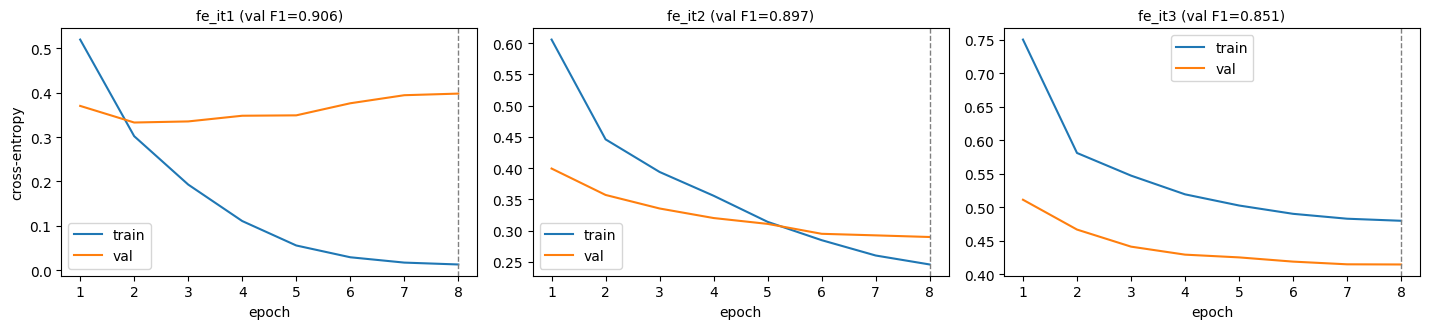

In [20]:
display(iter_table('fe')); plot_losses('fe')

### 4.c VGG-16 con fine-tuning


In [21]:
FT_CFGS = [
    dict(name='ft_it1', family='ft', n_unfrozen=1, aug=True, head_drop=0.5, opt='adamw', lr=1e-4, lr_bb=1e-5, wd=1e-4, epochs=8, patience=3),
    dict(name='ft_it2', family='ft', n_unfrozen=2, aug=True, head_drop=0.5, opt='adamw', lr=1e-4, lr_bb=1e-5, wd=1e-4, epochs=8, patience=3),
    dict(name='ft_it3', family='ft', n_unfrozen=2, aug=True, head_drop=0.5, opt='adamw', lr=1e-4, lr_bb=1e-4, wd=1e-4, epochs=8, patience=3),
]
run_iterations(FT_CFGS)


===== ft_it1 =====
ep 01 | train 0.5526 | val 0.3612 | acc 0.8728 | f1 0.8722 | 65.5s
ep 02 | train 0.3661 | val 0.3100 | acc 0.8914 | f1 0.8910 | 59.8s
ep 03 | train 0.3025 | val 0.2910 | acc 0.9030 | f1 0.9027 | 59.7s
ep 04 | train 0.2594 | val 0.2738 | acc 0.9058 | f1 0.9058 | 59.8s
ep 05 | train 0.2176 | val 0.2572 | acc 0.9158 | f1 0.9157 | 59.8s
ep 06 | train 0.1866 | val 0.2522 | acc 0.9164 | f1 0.9164 | 59.8s
ep 07 | train 0.1630 | val 0.2545 | acc 0.9184 | f1 0.9184 | 59.7s
ep 08 | train 0.1499 | val 0.2538 | acc 0.9194 | f1 0.9194 | 59.7s
-> nuevo mejor modelo ft

===== ft_it2 =====
ep 01 | train 0.4867 | val 0.3033 | acc 0.8958 | f1 0.8951 | 82.3s
ep 02 | train 0.2873 | val 0.2578 | acc 0.9130 | f1 0.9130 | 71.2s
ep 03 | train 0.2264 | val 0.2348 | acc 0.9218 | f1 0.9215 | 71.2s
ep 04 | train 0.1851 | val 0.2182 | acc 0.9248 | f1 0.9247 | 71.2s
ep 05 | train 0.1465 | val 0.2210 | acc 0.9308 | f1 0.9309 | 71.2s
ep 06 | train 0.1180 | val 0.2167 | acc 0.9336 | f1 0.9334 | 71.

,iter,config,congeladas,params tot (M),params entr (M),best ep,epochs,val acc,val prec,val rec,val F1,s/epoch,total (min),GPU pico (GB)
0,ft_it1,"n_unfrozen=1, aug=True, head_drop=0.5, opt=ada...",features bloques 1-4,134.3015,126.6662,8,8,0.9194,0.9196,0.9194,0.9194,60.4779,8.0637,3.1964
1,ft_it2,"n_unfrozen=2, aug=True, head_drop=0.5, opt=ada...",features bloques 1-3,134.3015,132.5660,7,8,0.9352,0.9355,0.9352,0.9353,72.5782,9.6771,4.5554
2,ft_it3,"n_unfrozen=2, aug=True, head_drop=0.5, opt=ada...",features bloques 1-3,134.3015,132.5660,8,8,0.9512,0.9514,0.9512,0.9512,71.0829,9.4777,3.2682


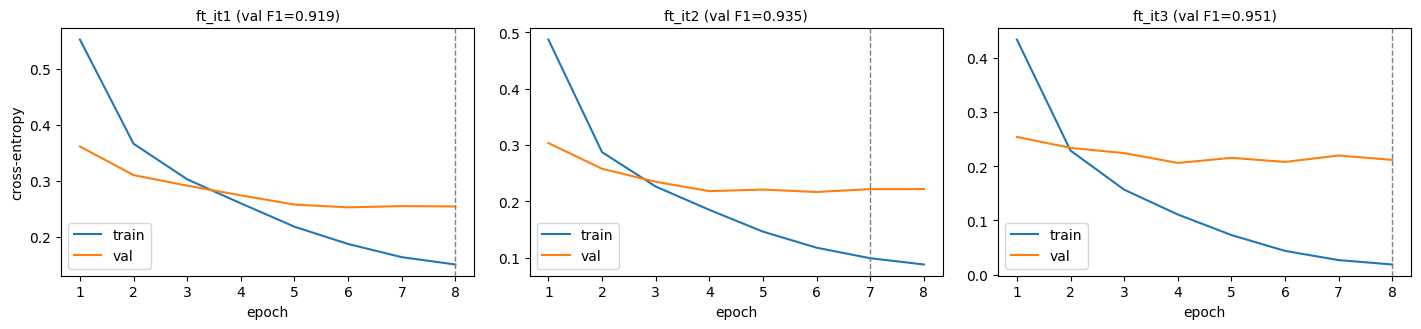

In [22]:
display(iter_table('ft')); plot_losses('ft')

In [23]:
# Registro completo: loss y métricas por epoch de cada iteración
for name, r in ALL_RESULTS.items():
    if r['frac'] == 1.0:
        print(f'\n{name}  ({r["frozen"]})'); display(epoch_table(name))


cnn_it1  (ninguna)


,train_loss,val_loss,val_acc,val_precision,val_recall,val_f1,epoch_time
epoch,,,,,,,
1,1.2467,1.3525,0.5338,0.6336,0.5338,0.5335,24.5793
2,0.8216,0.9321,0.6832,0.7524,0.6832,0.6896,2.5946
3,0.6611,0.9498,0.6790,0.7764,0.6790,0.6924,2.5730
4,0.5559,0.7286,0.7536,0.7868,0.7536,0.7553,2.6937
5,0.4812,0.8946,0.7126,0.8057,0.7126,0.7183,2.7477
6,0.4192,0.5518,0.8174,0.8254,0.8174,0.8162,2.5326
7,0.3606,0.6007,0.8042,0.8212,0.8042,0.8027,2.5854
8,0.3086,0.6731,0.7882,0.8152,0.7882,0.7856,2.5308
9,0.2657,0.7107,0.7848,0.8126,0.7848,0.7828,2.8769



cnn_it2  (ninguna)


,train_loss,val_loss,val_acc,val_precision,val_recall,val_f1,epoch_time
epoch,,,,,,,
1,1.4550,1.1747,0.5824,0.6009,0.5824,0.5692,26.7468
2,1.0542,0.8821,0.6916,0.7062,0.6916,0.6901,5.1317
3,0.9008,1.0747,0.6666,0.6891,0.6666,0.6572,5.1205
4,0.7992,0.7901,0.7150,0.7442,0.7150,0.7114,5.1958
5,0.7283,0.6635,0.7744,0.7924,0.7744,0.7772,5.2079
6,0.6667,0.6597,0.7822,0.8016,0.7822,0.7802,9.9393
7,0.6130,0.5567,0.8080,0.8180,0.8080,0.8077,6.0464
8,0.5720,0.5150,0.8298,0.8329,0.8298,0.8285,6.1759
9,0.5412,0.5210,0.8206,0.8378,0.8206,0.8162,6.0724



cnn_it3  (ninguna)


...

,train_loss,val_loss,val_acc,val_precision,val_recall,val_f1,epoch_time
epoch,,,,,,,
1,0.5526,0.3612,0.8728,0.8760,0.8728,0.8722,65.4653
2,0.3661,0.3100,0.8914,0.8917,0.8914,0.8910,59.7930
3,0.3025,0.2910,0.9030,0.9039,0.9030,0.9027,59.7160
4,0.2594,0.2738,0.9058,0.9073,0.9058,0.9058,59.7916
5,0.2176,0.2572,0.9158,0.9165,0.9158,0.9157,59.7500
6,0.1866,0.2522,0.9164,0.9165,0.9164,0.9164,59.8451
7,0.1630,0.2545,0.9184,0.9188,0.9184,0.9184,59.7372
8,0.1499,0.2538,0.9194,0.9196,0.9194,0.9194,59.7248



ft_it2  (features bloques 1-3)


,train_loss,val_loss,val_acc,val_precision,val_recall,val_f1,epoch_time
epoch,,,,,,,
1,0.4867,0.3033,0.8958,0.8980,0.8958,0.8951,82.2921
2,0.2873,0.2578,0.9130,0.9137,0.9130,0.9130,71.1754
3,0.2264,0.2348,0.9218,0.9220,0.9218,0.9215,71.2260
4,0.1851,0.2182,0.9248,0.9252,0.9248,0.9247,71.1952
5,0.1465,0.2210,0.9308,0.9315,0.9308,0.9309,71.1634
6,0.1180,0.2167,0.9336,0.9334,0.9336,0.9334,71.1488
7,0.0994,0.2218,0.9352,0.9355,0.9352,0.9353,71.2271
8,0.0883,0.2219,0.9340,0.9340,0.9340,0.9339,71.1973



ft_it3  (features bloques 1-3)


,train_loss,val_loss,val_acc,val_precision,val_recall,val_f1,epoch_time
epoch,,,,,,,
1,0.4333,0.2539,0.9154,0.9156,0.9154,0.9148,71.2885
2,0.2287,0.2336,0.9214,0.9240,0.9214,0.9216,71.1723
3,0.1566,0.2240,0.9296,0.9295,0.9296,0.9293,71.1818
4,0.1109,0.2059,0.9350,0.9369,0.9350,0.9351,71.1792
5,0.0730,0.2153,0.9390,0.9417,0.9390,0.9394,71.1293
6,0.0437,0.2078,0.9478,0.9481,0.9478,0.9478,71.0551
7,0.0268,0.2196,0.9470,0.9479,0.9470,0.9472,70.9042
8,0.0187,0.2115,0.9512,0.9514,0.9512,0.9512,70.7530


### 4.d Evaluación final en test (una sola vez por modelo)

In [24]:
FAMS = ['cnn', 'fe', 'ft']
NICE = {'cnn': 'CNN desde cero', 'fe': 'VGG-16 feature extractor', 'ft': 'VGG-16 fine-tuning'}
BEST_NAME = {f: max((r for r in ALL_RESULTS.values() if r['family'] == f and r['frac'] == 1.0),
                    key=lambda r: r['best_val']['f1'])['name'] for f in FAMS}
print(BEST_NAME)

def load_best(fam):
    m = build_model(ALL_RESULTS[BEST_NAME[fam]]['cfg']).to(device)
    m.load_state_dict(torch.load(f'{RESULTS_DIR}/best_{fam}.pt', map_location=device)); return m

BEST_MODELS, TEST_PRED = {}, {}
for fam in FAMS:
    BEST_MODELS[fam] = load_best(fam)
    m, t, p = evaluate(BEST_MODELS[fam], test_loader[KIND[fam]])
    ALL_RESULTS[BEST_NAME[fam]]['test'] = m; TEST_PRED[fam] = (t, p)
save_results()
display(pd.DataFrame({NICE[f]: ALL_RESULTS[BEST_NAME[f]]['test'] for f in FAMS}).T.round(4))

{'cnn': 'cnn_it3', 'fe': 'fe_it1', 'ft': 'ft_it3'}


,loss,acc,precision,recall,f1
CNN desde cero,0.2590,0.9218,0.9218,0.9218,0.9215
VGG-16 feature extractor,0.4371,0.8974,0.8975,0.8974,0.8974
VGG-16 fine-tuning,0.2327,0.9469,0.9469,0.9469,0.9468


CNN desde cero -> pares más confundidos: [('cat', 'dog', 166), ('bird', 'deer', 47), ('airplane', 'ship', 43), ('automobile', 'truck', 41), ('cat', 'frog', 39)]
VGG-16 feature extractor -> pares más confundidos: [('cat', 'dog', 185), ('automobile', 'truck', 90), ('bird', 'deer', 73), ('airplane', 'ship', 62), ('deer', 'horse', 55)]
VGG-16 fine-tuning -> pares más confundidos: [('cat', 'dog', 127), ('automobile', 'truck', 49), ('airplane', 'ship', 32), ('bird', 'deer', 31), ('deer', 'dog', 27)]


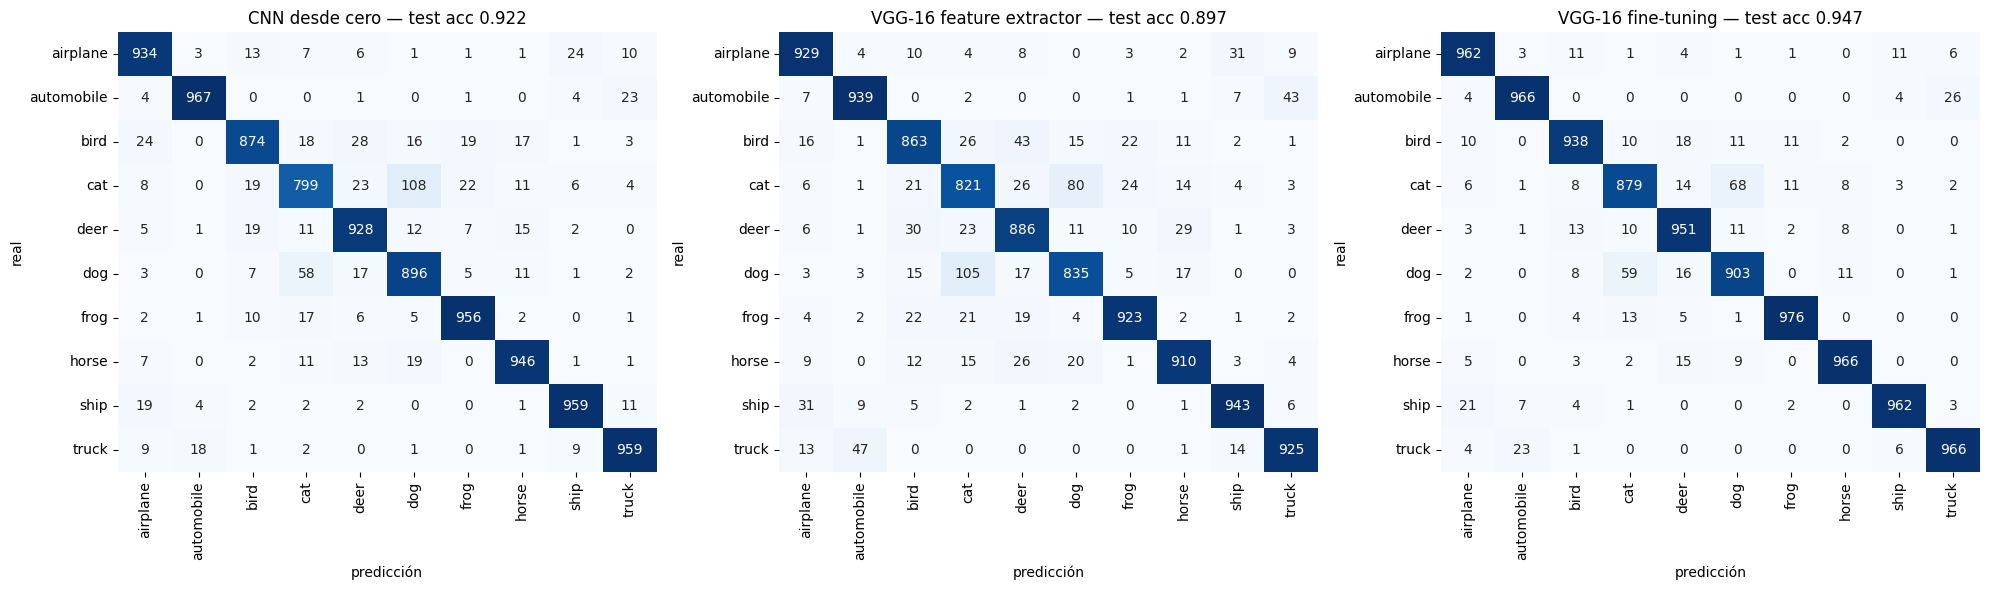


CNN desde cero
              precision    recall  f1-score   support

    airplane     0.9202    0.9340    0.9270      1000
  automobile     0.9728    0.9670    0.9699      1000
        bird     0.9229    0.8740    0.8978      1000
         cat     0.8638    0.7990    0.8301      1000
        deer     0.9062    0.9280    0.9170      1000
         dog     0.8469    0.8960    0.8707      1000
        frog     0.9456    0.9560    0.9508      1000
       horse     0.9413    0.9460    0.9436      1000
        ship     0.9523    0.9590    0.9557      1000
       truck     0.9458    0.9590    0.9523      1000

    accuracy                         0.9218     10000
   macro avg     0.9218    0.9218    0.9215     10000
weighted avg     0.9218    0.9218    0.9215     10000


VGG-16 feature extractor
              precision    recall  f1-score   support

    airplane     0.9072    0.9290    0.9180      1000
  automobile     0.9325    0.9390    0.9357      1000
        bird     0.8824    0.8630   

In [25]:
def top_confusions(cm, k=5):
    c = cm.copy(); np.fill_diagonal(c, 0); s = c + c.T
    iu = np.triu_indices(10, 1); vals = s[iu]
    return [(CLASSES[iu[0][o]], CLASSES[iu[1][o]], int(vals[o])) for o in np.argsort(vals)[::-1][:k]]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, fam in zip(axes, FAMS):
    t, p = TEST_PRED[fam]; cm = confusion_matrix(t, p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, cbar=False, ax=ax)
    ax.set_title(f"{NICE[fam]} — test acc {ALL_RESULTS[BEST_NAME[fam]]['test']['acc']:.3f}")
    ax.set_xlabel('predicción'); ax.set_ylabel('real')
    print(NICE[fam], '-> pares más confundidos:', top_confusions(cm))
plt.tight_layout(); plt.show()

for fam in FAMS:
    print(f'\n{NICE[fam]}'); print(classification_report(*TEST_PRED[fam], target_names=CLASSES, digits=4))

### 4.1 Efecto de la cantidad de datos (10 % estratificado)


In [26]:
for fam in FAMS:
    base = copy.deepcopy(ALL_RESULTS[BEST_NAME[fam]]['cfg'])
    cfg = {**base, 'name': base['name'] + '_10pct', 'epochs': base['epochs'] * 2, 'patience': base.get('patience', 999) * 2}
    if cfg['name'] in ALL_RESULTS and 'test' in ALL_RESULTS[cfg['name']]:
        print(cfg['name'], 'ya existe'); continue
    print(f"\n===== {cfg['name']} =====")
    res, model = train_model(cfg, train_idx=tr10_idx)
    res['test'], _, _ = evaluate(model, test_loader[KIND[fam]])
    ALL_RESULTS[cfg['name']] = res; save_results()
    del model; gc.collect(); torch.cuda.empty_cache()

rows = []
for fam in FAMS:
    full, small = ALL_RESULTS[BEST_NAME[fam]]['test'], ALL_RESULTS[BEST_NAME[fam] + '_10pct']['test']
    rows.append({'modelo': NICE[fam], 'acc 100%': full['acc'], 'acc 10%': small['acc'],
                 'F1 100%': full['f1'], 'F1 10%': small['f1'], 'caída F1 (pts)': 100 * (full['f1'] - small['f1']),
                 'caída relativa (%)': 100 * (full['f1'] - small['f1']) / full['f1']})
data_df = pd.DataFrame(rows).set_index('modelo').round(4); display(data_df)
display(iter_table(frac=0.1))


===== cnn_it3_10pct =====
ep 01 | train 3.1915 | val 5.0750 | acc 0.1258 | f1 0.0419 | 12.8s
ep 02 | train 2.5900 | val 2.3531 | acc 0.1152 | f1 0.0451 | 0.7s
ep 03 | train 2.4386 | val 2.4825 | acc 0.1384 | f1 0.0601 | 0.7s
ep 04 | train 2.3811 | val 2.2955 | acc 0.1382 | f1 0.0834 | 0.7s
ep 05 | train 2.2170 | val 2.0421 | acc 0.1990 | f1 0.1336 | 0.7s
ep 06 | train 2.0493 | val 2.1015 | acc 0.2036 | f1 0.1467 | 0.7s
ep 07 | train 1.9928 | val 1.9950 | acc 0.2412 | f1 0.2018 | 0.7s
ep 08 | train 1.8814 | val 1.8979 | acc 0.2712 | f1 0.2457 | 0.7s
ep 09 | train 1.8090 | val 1.9481 | acc 0.2810 | f1 0.2538 | 0.7s
ep 10 | train 1.8035 | val 1.7639 | acc 0.3272 | f1 0.3045 | 0.7s
ep 11 | train 1.7308 | val 1.8505 | acc 0.3088 | f1 0.2759 | 0.7s
ep 12 | train 1.7035 | val 1.7655 | acc 0.3372 | f1 0.3260 | 0.7s
ep 13 | train 1.6566 | val 2.1129 | acc 0.2924 | f1 0.2906 | 0.7s
ep 14 | train 1.6976 | val 1.7514 | acc 0.3386 | f1 0.3239 | 0.7s
ep 15 | train 1.6000 | val 1.6567 | acc 0.3818 |

,acc 100%,acc 10%,F1 100%,F1 10%,caída F1 (pts),caída relativa (%)
modelo,,,,,,
CNN desde cero,0.9218,0.7425,0.9215,0.7424,17.9078,19.4332
VGG-16 feature extractor,0.8974,0.8495,0.8974,0.8494,4.8019,5.3510
VGG-16 fine-tuning,0.9469,0.8969,0.9468,0.8965,5.0302,5.3125


,iter,config,congeladas,params tot (M),params entr (M),best ep,epochs,val acc,val prec,val rec,val F1,s/epoch,total (min),GPU pico (GB)
0,cnn_it3_10pct,"widths=(64, 128, 256, 512), drop=0.25, fc_drop...",ninguna,4.6924,4.6924,74,80,0.7448,0.7466,0.7448,0.7451,0.8120,1.0827,0.6866
1,fe_it1_10pct,"aug=False, head_drop=0.5, opt=adamw, lr=0.0001...",features bloques 1-5 (todo el backbone),134.3015,119.5868,16,16,0.8524,0.8530,0.8524,0.8524,5.4012,1.4403,3.1008
2,ft_it3_10pct,"n_unfrozen=2, aug=True, head_drop=0.5, opt=ada...",features bloques 1-3,134.3015,132.5660,13,16,0.9022,0.9024,0.9022,0.9021,7.6724,2.0460,4.4452


## 5. Comparación de rendimiento y recursos

In [27]:
def macs_info(model, fam, cfg):
    s = PREP[KIND[fam]]['size']; model.eval()
    fca = FlopCountAnalysis(model, torch.randn(1, 3, s, s, device=device))
    fca.unsupported_ops_warnings(False).uncalled_modules_warnings(False)
    total, bm = fca.total(), fca.by_module()
    if fam == 'cnn':
        bwd = total
    elif fam == 'fe':
        bwd = bm['classifier']
    else:
        start = VGG_BLOCKS[5 - cfg['n_unfrozen']][0]
        bwd = sum(bm[f'features.{i}'] for i in range(start, 31)) + bm['avgpool'] + bm['classifier']
    return total, bwd

@torch.no_grad()
def latency_ms(model, size, bs=1, iters=100, warmup=20):
    model.eval(); x = torch.randn(bs, 3, size, size, device=device)
    for _ in range(warmup): model(x)
    torch.cuda.synchronize(); t0 = time.perf_counter()
    for _ in range(iters): model(x)
    torch.cuda.synchronize()
    return (time.perf_counter() - t0) / iters / bs * 1000

COMP = {}
for fam in FAMS:
    r, model = ALL_RESULTS[BEST_NAME[fam]], BEST_MODELS[fam]
    size = PREP[KIND[fam]]['size']
    macs, macs_bwd = macs_info(model, fam, r['cfg'])
    train_flops_img = 2 * macs + 2 * (2 * macs_bwd)
    te, te10 = r['test'], ALL_RESULTS[BEST_NAME[fam] + '_10pct']['test']
    COMP[NICE[fam]] = {
        'Params totales (M)': r['total_params'] / 1e6, 'Params entrenables (M)': r['trainable_params'] / 1e6,
        'MACs/img (G)': macs / 1e9, 'FLOPs/img inferencia (G)': 2 * macs / 1e9,
        'Latencia bs=1 (ms/img)': latency_ms(model, size, 1), 'Latencia bs=128 (ms/img)': latency_ms(model, size, 128, iters=20, warmup=5),
        's/epoch': r['time_per_epoch'], 'Epoch mejor val': r['best_epoch'], 'Epochs corridos': r['epochs_run'],
        'Tiempo hasta mejor (min)': r['time_to_best'] / 60, 'Tiempo total (min)': r['time_total'] / 60,
        'Memoria pico GPU (GB)': r['peak_mem_gb'],
        'FLOPs entrenamiento/img (G)': train_flops_img / 1e9,
        'Cómputo entrenamiento total (PFLOPs)': train_flops_img * r['train_size'] * r['epochs_run'] / 1e15,
        'Cómputo hasta mejor epoch (PFLOPs)': train_flops_img * r['train_size'] * r['best_epoch'] / 1e15,
        'Test acc': te['acc'], 'Test precision': te['precision'], 'Test recall': te['recall'], 'Test F1': te['f1'],
        'Test acc (10%)': te10['acc'], 'Test F1 (10%)': te10['f1'],
    }
comp_df = pd.DataFrame(COMP)
comp_df.to_csv(f'{RESULTS_DIR}/comparacion.csv')
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')
display(comp_df)
print('Hardware:', torch.cuda.get_device_name(0))

,CNN desde cero,VGG-16 feature extractor,VGG-16 fine-tuning
Params totales (M),4.6924,134.3015,134.3015
Params entrenables (M),4.6924,119.5868,132.5660
MACs/img (G),0.2099,5.1307,5.1307
FLOPs/img inferencia (G),0.4198,10.2615,10.2615
Latencia bs=1 (ms/img),1.1192,4.9096,4.9090
Latencia bs=128 (ms/img),0.0773,1.5299,1.5291
s/epoch,6.8565,53.7296,71.0829
Epoch mejor val,39.0000,8.0000,8.0000
Epochs corridos,40.0000,8.0000,8.0000
Tiempo hasta mejor (min),4.4626,7.1639,9.4777


Hardware: Tesla T4


In [28]:
for fam in FAMS:
    s = PREP[KIND[fam]]['size']
    print(f'\n##### {NICE[fam]} ({BEST_NAME[fam]})')
    print(summary(BEST_MODELS[fam], input_size=(1, 3, s, s), depth=2, verbose=0,
                  col_names=('output_size', 'num_params', 'trainable', 'mult_adds')))


##### CNN desde cero (cnn_it3)
Layer (type:depth-idx)                   Output Shape              Param #                   Trainable                 Mult-Adds
SimpleCNN                                [1, 10]                   --                        True                      --
├─Sequential: 1-1                        [1, 512, 2, 2]            --                        True                      --
│    └─ConvBlock: 2-1                    [1, 64, 16, 16]           38,848                    True                      39,518,464
│    └─ConvBlock: 2-2                    [1, 128, 8, 8]            221,696                   True                      56,623,616
│    └─ConvBlock: 2-3                    [1, 256, 4, 4]            885,760                   True                      56,624,128
│    └─ConvBlock: 2-4                    [1, 512, 2, 2]            3,540,992                 True                      56,625,152
├─AdaptiveAvgPool2d: 1-2                 [1, 512, 1, 1]            --      

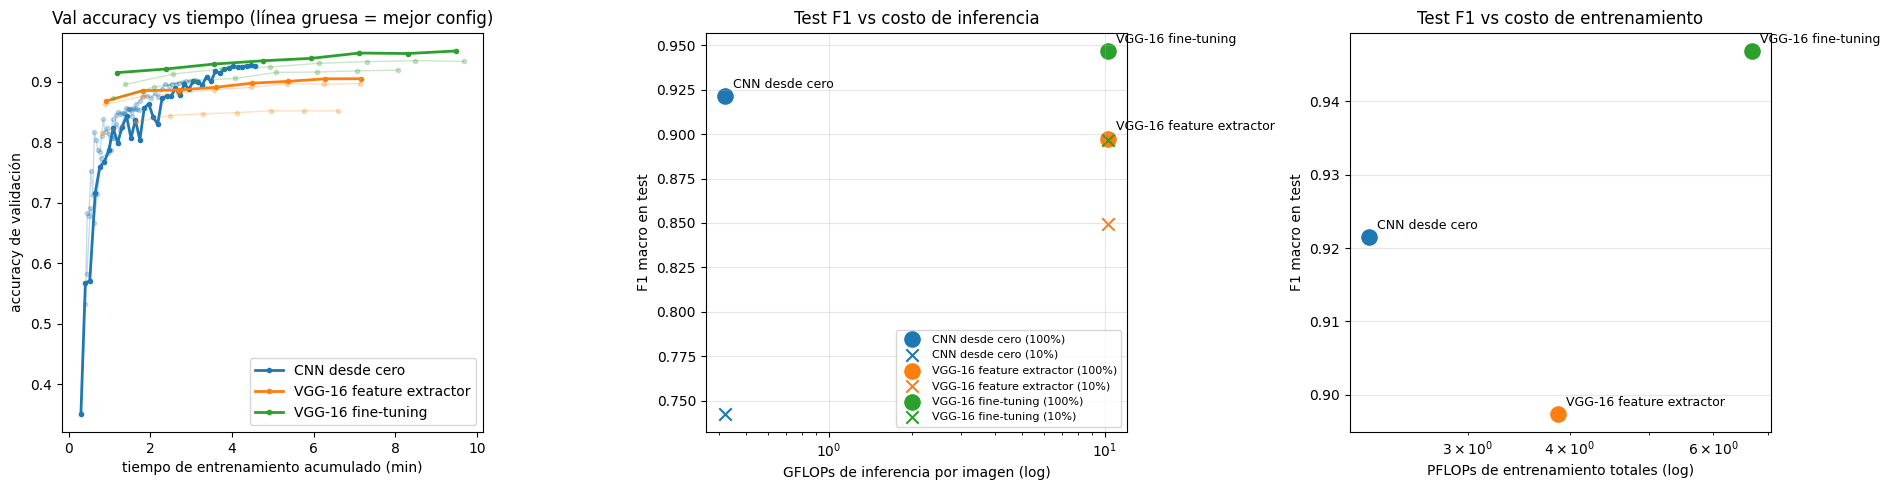

In [29]:
colors = dict(zip(FAMS, ['tab:blue', 'tab:orange', 'tab:green']))
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

ax = axes[0]
for fam in FAMS:
    for r in (r for r in ALL_RESULTS.values() if r['family'] == fam and r['frac'] == 1.0):
        best = r['name'] == BEST_NAME[fam]
        ax.plot(np.cumsum(r['hist']['epoch_time']) / 60, r['hist']['val_acc'], marker='o', ms=3,
                color=colors[fam], alpha=1 if best else 0.25, lw=2 if best else 1,
                label=NICE[fam] if best else None)
ax.set_xlabel('tiempo de entrenamiento acumulado (min)'); ax.set_ylabel('accuracy de validación')
ax.set_title('Val accuracy vs tiempo (línea gruesa = mejor config)'); ax.legend()

for ax, col, xl in [(axes[1], 'FLOPs/img inferencia (G)', 'GFLOPs de inferencia por imagen (log)'),
                    (axes[2], 'Cómputo entrenamiento total (PFLOPs)', 'PFLOPs de entrenamiento totales (log)')]:
    for fam in FAMS:
        c = comp_df[NICE[fam]]
        ax.scatter(c[col], c['Test F1'], s=120, color=colors[fam], label=f'{NICE[fam]} (100%)')
        ax.annotate(NICE[fam], (c[col], c['Test F1']), textcoords='offset points', xytext=(6, 6), fontsize=9)
        if col.startswith('FLOPs'):
            ax.scatter(c[col], c['Test F1 (10%)'], s=80, marker='x', color=colors[fam], label=f'{NICE[fam]} (10%)')
    ax.set_xscale('log'); ax.set_xlabel(xl); ax.set_ylabel('F1 macro en test'); ax.grid(alpha=0.3)
axes[1].set_title('Test F1 vs costo de inferencia'); axes[1].legend(fontsize=8)
axes[2].set_title('Test F1 vs costo de entrenamiento')
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/comparacion.png', dpi=150); plt.show()

In [30]:
# Cifras de apoyo para la discusión
ref = comp_df[NICE['cnn']]
for fam in FAMS:
    c = comp_df[NICE[fam]]
    print(f"{NICE[fam]:<26} ΔF1 vs CNN: {100*(c['Test F1']-ref['Test F1']):+6.2f} pts | "
          f"FLOPs inf x{c['FLOPs/img inferencia (G)']/ref['FLOPs/img inferencia (G)']:6.1f} | "
          f"params x{c['Params totales (M)']/ref['Params totales (M)']:6.1f} | "
          f"tiempo total x{c['Tiempo total (min)']/ref['Tiempo total (min)']:5.1f} | "
          f"F1 por PFLOP de entrenamiento: {c['Test F1']/c['Cómputo entrenamiento total (PFLOPs)']:.4f}")

CNN desde cero             ΔF1 vs CNN:  +0.00 pts | FLOPs inf x   1.0 | params x   1.0 | tiempo total x  1.0 | F1 por PFLOP de entrenamiento: 0.4065
VGG-16 feature extractor   ΔF1 vs CNN:  -2.41 pts | FLOPs inf x  24.4 | params x  28.6 | tiempo total x  1.6 | F1 por PFLOP de entrenamiento: 0.2321
VGG-16 fine-tuning         ΔF1 vs CNN:  +2.53 pts | FLOPs inf x  24.4 | params x  28.6 | tiempo total x  2.1 | F1 por PFLOP de entrenamiento: 0.1415


In [31]:
save_results()
print('Resultados guardados en', RESULTS_DIR, '->', os.listdir(RESULTS_DIR))

Resultados guardados en /content/results -> ['results.json', 'comparacion.csv', 'best_cnn.pt', 'best_ft.pt', 'comparacion.png', 'best_fe.pt']
